In [ ]:
"""
Exploratory Data Analysis (EDA) - Online Food Delivery Dataset
Internship Task 2

Author: <Your Name>
Description:
    This script performs EDA on the "Online Food Delivery" survey dataset.
    It uses pandas for data handling and matplotlib/seaborn for visualization.
    Outputs (charts) are saved to the 'outputs' folder.
"""

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# ---------------------------------------------------------
# 0. Setup
# ---------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
DATA_PATH = "data/online food delivery dataset.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
df = pd.read_csv(DATA_PATH)

In [5]:
# Drop the unnamed/duplicate column (survey export artifact)
if "Unnamed: 13" in df.columns:
    df = df.drop(columns=["Unnamed: 13"])

In [7]:
# Clean whitespace issues in categorical text (e.g. "Negative ")
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9116\2317483988.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [8]:
print("Dataset shape:", df.shape)
print("\nColumn info:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (388, 13)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    str    
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    str    
 12  Feedback                    388 non-null    str    
dtypes: floa

In [9]:
# ---------------------------------------------------------
# 2. Summary Statistics
# ---------------------------------------------------------
print("\nNumerical summary:")
print(df.describe())


Numerical summary:
              Age  Family size    latitude   longitude       Pin code
count  388.000000   388.000000  388.000000  388.000000     388.000000
mean    24.628866     3.280928   12.972058   77.600160  560040.113402
std      2.975593     1.351025    0.044489    0.051354      31.399609
min     18.000000     1.000000   12.865200   77.484200  560001.000000
25%     23.000000     2.000000   12.936900   77.565275  560010.750000
50%     24.000000     3.000000   12.977000   77.592100  560033.500000
75%     26.000000     4.000000   12.997025   77.630900  560068.000000
max     33.000000     6.000000   13.102000   77.758200  560109.000000


In [10]:
print("\nCategorical value counts:")
for col in ["Gender", "Marital Status", "Occupation", "Monthly Income",
            "Educational Qualifications", "Customer Type", "Output", "Feedback"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categorical value counts:

Gender:
Gender
Male      222
Female    166
Name: count, dtype: int64

Marital Status:
Marital Status
Single               268
Married              108
Prefer not to say     12
Name: count, dtype: int64

Occupation:
Occupation
Student           207
Employee          118
Self Employeed     54
House wife          9
Name: count, dtype: int64

Monthly Income:
Monthly Income
No Income          187
25001 to 50000      69
More than 50000     62
10001 to 25000      45
Below Rs.10000      25
Name: count, dtype: int64

Educational Qualifications:
Educational Qualifications
Graduate         177
Post Graduate    174
Ph.D              23
School            12
Uneducated         2
Name: count, dtype: int64

Customer Type:
Customer Type
Regular     218
Frequent    146
New          24
Name: count, dtype: int64

Output:
Output
Yes    301
No      87
Name: count, dtype: int64

Feedback:
Feedback
Positive    317
Negative     71
Name: count, dtype: int64


Text(0.5, 0, 'Age')

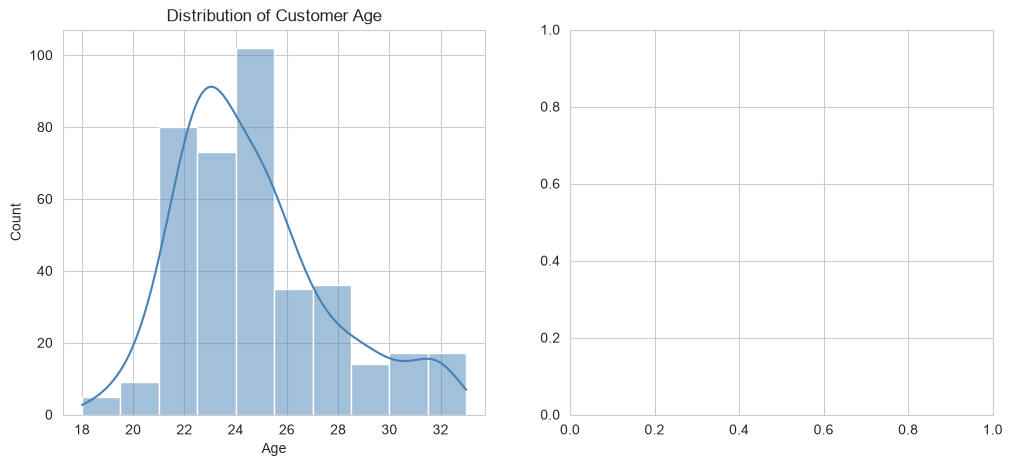

In [11]:
# ---------------------------------------------------------
# 3. Histograms (distribution of numerical features)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["Age"], bins=10, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Customer Age")
axes[0].set_xlabel("Age")

In [12]:
sns.histplot(df["Family size"], bins=6, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Family Size")
axes[1].set_xlabel("Family Size")

Text(0.5, 23.111490885416664, 'Family Size')

In [13]:
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_histograms_age_familysize.png", dpi=150)
plt.show()

<Figure size 800x500 with 0 Axes>

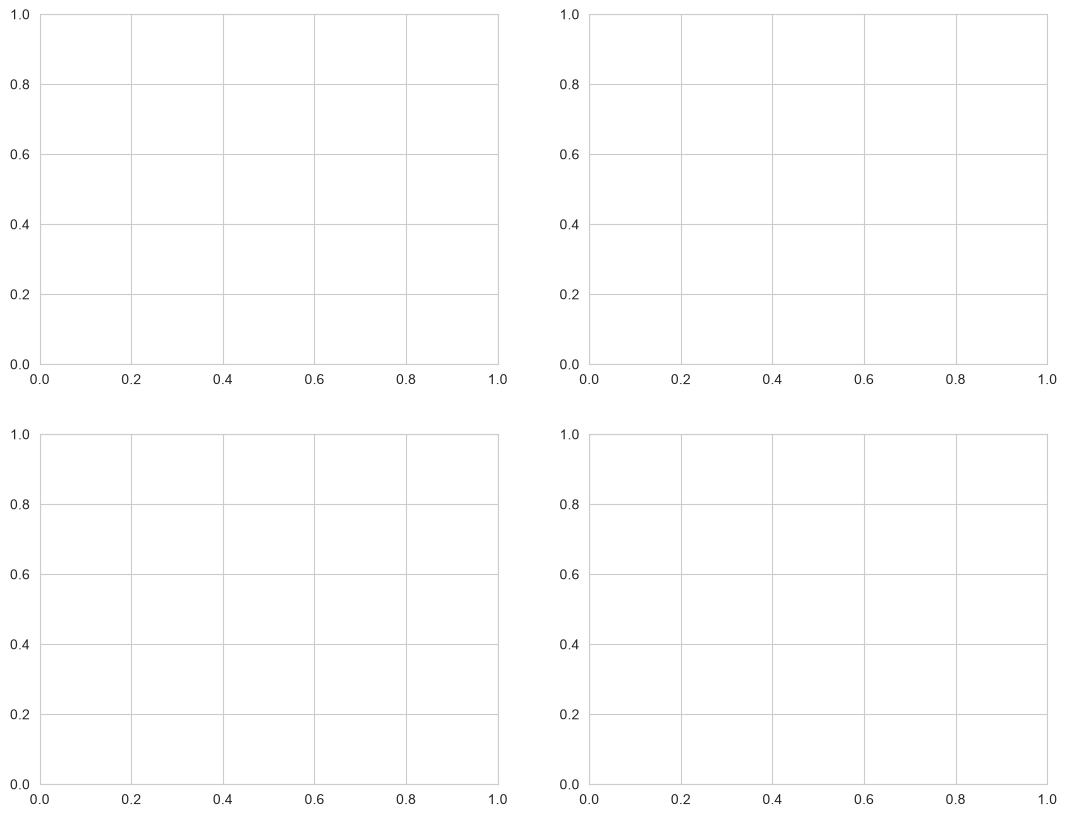

In [14]:
# ---------------------------------------------------------
# 4. Bar Charts (categorical features)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

In [15]:
sns.countplot(data=df, x="Gender", ax=axes[0, 0], hue="Gender", legend=False, palette="Set2")
axes[0, 0].set_title("Customers by Gender")

Text(0.5, 1.0, 'Customers by Gender')

In [16]:
sns.countplot(data=df, x="Occupation", ax=axes[0, 1], hue="Occupation", legend=False, palette="Set2")
axes[0, 1].set_title("Customers by Occupation")
axes[0, 1].tick_params(axis="x", rotation=20)

In [17]:
sns.countplot(data=df, x="Monthly Income", ax=axes[1, 0], hue="Monthly Income", legend=False,
              order=df["Monthly Income"].value_counts().index, palette="Set2")
axes[1, 0].set_title("Customers by Monthly Income")
axes[1, 0].tick_params(axis="x", rotation=20)

In [18]:
sns.countplot(data=df, x="Feedback", ax=axes[1, 1], hue="Feedback", legend=False, palette="Set2")
axes[1, 1].set_title("Customer Feedback")

Text(0.5, 1.0, 'Customer Feedback')

In [19]:
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_barcharts_categorical.png", dpi=150)
plt.show()

<Figure size 800x500 with 0 Axes>

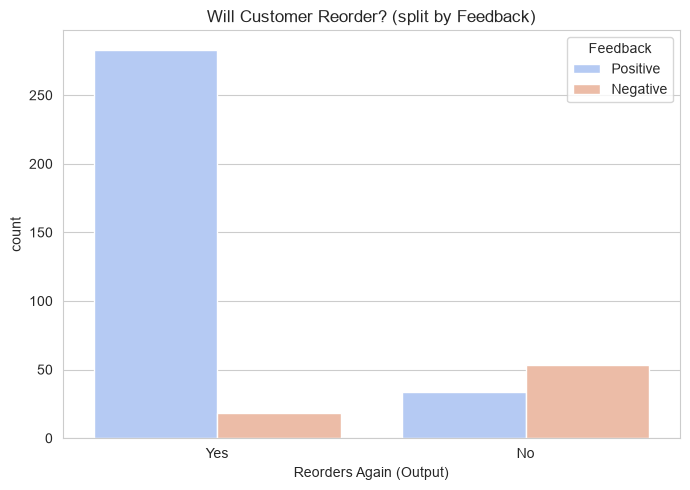

In [20]:
# ---------------------------------------------------------
# 5. Reordering App Usage (Output) vs Feedback
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Output", hue="Feedback", palette="coolwarm")
plt.title("Will Customer Reorder? (split by Feedback)")
plt.xlabel("Reorders Again (Output)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_output_vs_feedback.png", dpi=150)
plt.show()

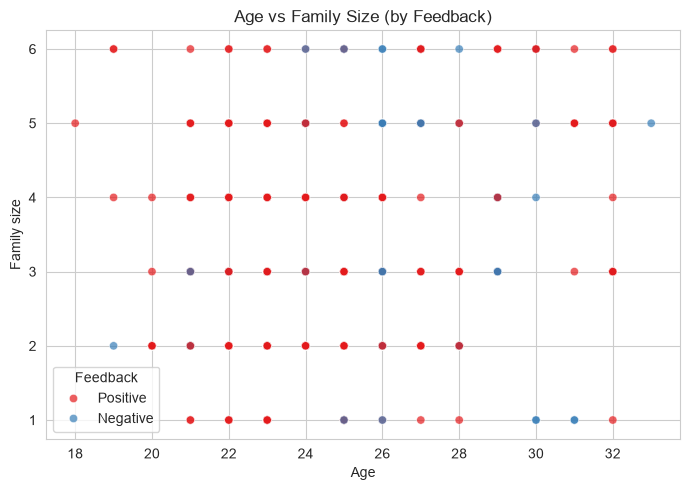

In [21]:
# ---------------------------------------------------------
# 6. Scatter Plot - Age vs Family Size (colored by Feedback)
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Age", y="Family size", hue="Feedback", alpha=0.7, palette="Set1")
plt.title("Age vs Family Size (by Feedback)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_scatter_age_familysize.png", dpi=150)
plt.show()

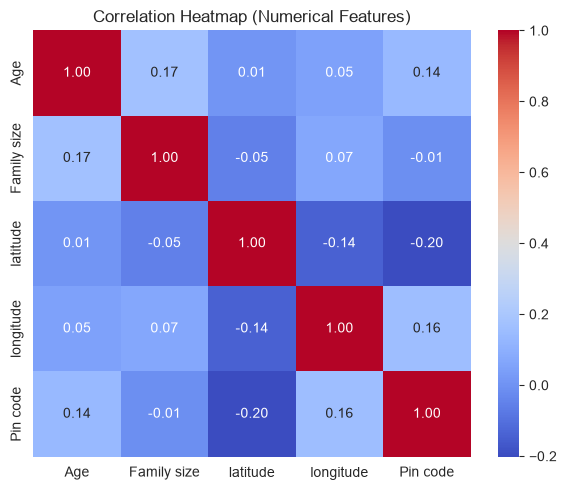

In [22]:
# ---------------------------------------------------------
# 7. Correlation Heatmap (numerical columns)
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
num_cols = ["Age", "Family size", "latitude", "longitude", "Pin code"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------
# 8. Boxplot - Detect Outliers in Age & Family Size
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=df["Age"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot - Age")
sns.boxplot(y=df["Family size"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot - Family Size")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_boxplots_outliers.png", dpi=150)
plt.show()

In [ ]:
print(f"\nAll charts saved to the '{OUTPUT_DIR}/' folder.")
print("EDA complete.")